NOTEBOOK 07 - MODEL EVALUATION & TESTING
TensorFlow Version : 2.20.0
GPU Available : []
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GOOGLE DRIVE MOUNTED SUCCESSFULLY
Project Path : /content/drive/MyDrive/Covid_Major_Project
Model Path   : /content/drive/MyDrive/Covid_Major_Project/models
Result Path  : /content/drive/MyDrive/Covid_Major_Project/results
LOADING BEST MOBILENETV2 MODEL
✓ MobileNetV2 Loaded Successfully
/content/drive/MyDrive/Covid_Major_Project
/content/drive/MyDrive/Covid_Major_Project/processed/test.csv
600
test_df rows: 600
VERIFY TEST CSV
Label Counts
Label
Lung_Opacity       150
Normal             150
Viral Pneumonia    150
COVID              150
Name: count, dtype: int64

Label_ID Counts
Label_ID
1    150
2    150
3    150
0    150
Name: count, dtype: int64

Label Encoder Classes
['COVID' 'Lung_Opacity' 'Normal' 'Viral Pneumonia']

Testing Images : 600
                              

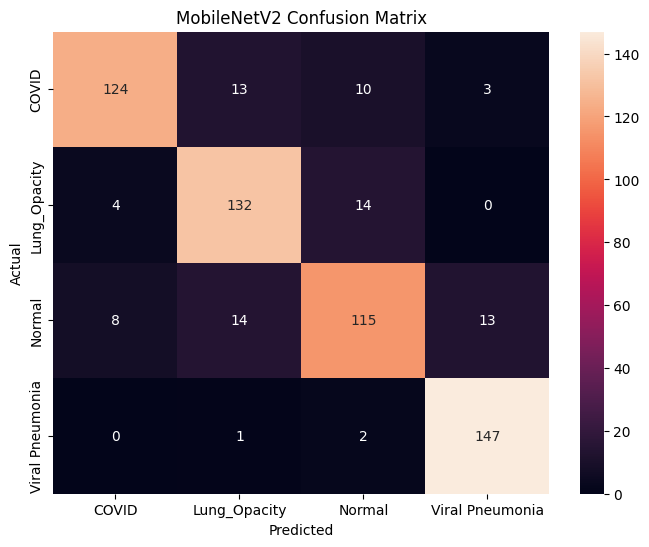

✓ Confusion Matrix Saved
✓ Evaluation Summary Saved
NOTEBOOK 07 COMPLETED SUCCESSFULLY


In [ ]:
# ============================================================
# NOTEBOOK 07 - MODEL EVALUATION & TESTING
# PART 1: IMPORT LIBRARIES AND SETUP
# ============================================================

import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

import seaborn as sns

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)


print("="*60)
print("NOTEBOOK 07 - MODEL EVALUATION & TESTING")
print("="*60)

print("TensorFlow Version :", tf.__version__)

print("GPU Available :", tf.config.list_physical_devices('GPU'))

print("="*60)


# Google Drive

from google.colab import drive

drive.mount('/content/drive')


print("="*60)
print("GOOGLE DRIVE MOUNTED SUCCESSFULLY")
print("="*60)


PROJECT_PATH = "/content/drive/MyDrive/Covid_Major_Project"

MODEL_PATH = PROJECT_PATH + "/models"

RESULT_PATH = PROJECT_PATH + "/results"

DATASET_ZIP = PROJECT_PATH + "/dataset/archive.zip"


print("Project Path :", PROJECT_PATH)
print("Model Path   :", MODEL_PATH)
print("Result Path  :", RESULT_PATH)

print("="*60)

# ============================================================
# LOAD MODEL
# ============================================================

print("="*60)
print("LOADING BEST MOBILENETV2 MODEL")
print("="*60)


model = load_model(
    MODEL_PATH + "/best_mobilenetv2.keras"
)


print("✓ MobileNetV2 Loaded Successfully")


print("="*60)


# ============================================================
# LOAD TEST CSV
# ============================================================

test_csv = PROJECT_PATH + "/processed/test.csv"

test_df = pd.read_csv(test_csv)

print(PROJECT_PATH)
print(test_csv)
print(len(test_df))

print("test_df rows:", len(test_df))

import pickle

with open(PROJECT_PATH + "/processed/label_encoder.pkl", "rb") as f:
    label_encoder = pickle.load(f)

print("="*60)
print("VERIFY TEST CSV")
print("="*60)

print("Label Counts")
print(test_df["Label"].value_counts())

print()

print("Label_ID Counts")
print(test_df["Label_ID"].value_counts())

print()

print("Label Encoder Classes")
print(label_encoder.classes_)

print()

print("Testing Images :", len(test_df))
print(test_df.head())

print("="*60)




# ============================================================
# EXTRACT DATASET
# ============================================================


print("="*60)
print("CHECKING DATASET")
print("="*60)


dataset_path = "/content/COVID19_Dataset/COVID-19_Radiography_Dataset"


import shutil

EXTRACT_PATH = "/content/COVID19_Dataset"



print("="*60)
print("EXTRACTING DATASET AGAIN")
print("="*60)

with zipfile.ZipFile(DATASET_ZIP, 'r') as zip_ref:
    zip_ref.extractall("/content")

print("✓ Dataset Extracted")

dataset_path = "/content/COVID-19_Radiography_Dataset"

print()
print("Checking extracted files")

print(os.listdir(dataset_path))


print()

print("Dataset Location:")
print(dataset_path)


print()

print("Classes:")
print(os.listdir(dataset_path))

dataset_path = "/content/COVID-19_Radiography_Dataset"

print("="*60)
print("VERIFY DATASET PATH")
print("="*60)

print("Exists:", os.path.exists(dataset_path))

print()

print("Classes:")
print(os.listdir(dataset_path))

import os

print("CONTENT OF /content/COVID19_Dataset")
print("="*60)

for root, dirs, files in os.walk("/content/COVID19_Dataset"):
    level = root.replace("/content/COVID19_Dataset", "").count(os.sep)
    indent = " " * 4 * level
    print(indent + os.path.basename(root) + "/")

    if level < 2:
        for f in files[:5]:
            print(indent + "    " + f)

print("="*60)

# ============================================================
# CREATE TEST DATASET
# ============================================================

def fix_path(row):

    filename = os.path.basename(row["Image"])

    label = row["Label"]

    return os.path.join(
        dataset_path,
        label,
        "images",
        filename
    )

# Create Fixed_Path column
test_df["Fixed_Path"] = test_df.apply(
    fix_path,
    axis=1
)

print("="*60)
print("VERIFY IMAGE PATHS")
print("="*60)

print(test_df[["Label", "Fixed_Path"]].head())

print()

for i in range(10):

    path = test_df.iloc[i]["Fixed_Path"]

    print(path, "->", os.path.exists(path))

missing = (~test_df["Fixed_Path"].apply(os.path.exists)).sum()

print()
print("Missing files :", missing)

print("="*60)


# ============================================================
# SINGLE IMAGE MODEL TEST
# ============================================================

sample = test_df.iloc[0]

print("Image:")
print(sample["Fixed_Path"])

print()

print("Actual Label:")
print(sample["Label"])

print()

print("Actual Label ID:")
print(sample["Label_ID"])


img = load_img(
    sample["Fixed_Path"],
    target_size=(224,224)
)

img = img_to_array(img)

from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

img = preprocess_input(img)


img = np.expand_dims(img, axis=0)


prediction = model.predict(img)


predicted_class = np.argmax(prediction)


print()

print("Predicted Label ID:")
print(predicted_class)


print()

print("Prediction Probabilities:")
print(prediction)




from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array

IMG_SIZE = (224, 224)

def preprocess_image(path):

    img = load_img(
        path,
        target_size=IMG_SIZE
    )

    img = img_to_array(img)

    img = preprocess_input(img)

    return img



def preprocess(path, label):

    image = tf.io.read_file(path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, (224,224))
    image = preprocess_input(image)

    return image, label


test_dataset = tf.data.Dataset.from_tensor_slices(
    (
        test_df["Fixed_Path"].values,
        test_df["Label_ID"].values
    )
)

test_dataset = test_dataset.map(
    preprocess,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_dataset = test_dataset.batch(32)

test_dataset = test_dataset.prefetch(
    tf.data.AUTOTUNE
)

print(
    "New Dataset Batches:",
    tf.data.experimental.cardinality(test_dataset).numpy()
)

y_test = test_df["Label_ID"].values



print("✓ Test Dataset Created")

print("Images :", len(test_df))


print("="*60)

# ============================================================
# PREDICTIONS
# ============================================================


print("="*60)
print("RUNNING MODEL PREDICTIONS")
print("="*60)


predictions = model.predict(
    test_dataset,
    verbose=1
)


y_pred = np.argmax(
    predictions,
    axis=1
)



print("✓ Predictions Generated")

print("First 20 Actual Labels")
print(y_test[:20])

print()

print("First 20 Predictions")
print(y_pred[:20])

print("Label Encoder Mapping")

for i, cls in enumerate(label_encoder.classes_):
    print(i, "=", cls)


for images, labels in test_dataset.take(1):
    print("Batch image shape:", images.shape)
    print("Batch labels:")
    print(labels.numpy()[:20])


print("First 20 prediction probabilities:")

for i in range(20):
    print(
        "Image", i,
        "Actual:", y_test[i],
        "Predicted:", y_pred[i],
        "Confidence:", round(np.max(predictions[i])*100,2), "%"
    )

print("="*60)

# ============================================================
# EVALUATION
# ============================================================


accuracy = accuracy_score(
    y_test,
    y_pred
)


print(
    "Test Accuracy:",
    round(accuracy*100,2),
    "%"
)



class_names = list(label_encoder.classes_)



report = classification_report(
    y_test,
    y_pred,
    target_names=class_names,
    digits=4
)



print(report)



with open(
    RESULT_PATH+"/mobilenetv2_classification_report.txt",
    "w"
) as f:

    f.write(report)



print("✓ Report Saved")


# Confusion Matrix


cm = confusion_matrix(
    y_test,
    y_pred
)


plt.figure(figsize=(8,6))


sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)


plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title(
    "MobileNetV2 Confusion Matrix"
)



plt.savefig(
    RESULT_PATH+"/mobilenetv2_confusion_matrix.png",
    bbox_inches="tight"
)


plt.show()



print("✓ Confusion Matrix Saved")


print("="*60)

# ============================================================
# SAVE SUMMARY
# ============================================================


summary = pd.DataFrame({

"Model":["MobileNetV2"],

"Test Samples":[len(y_test)],

"Accuracy":[round(accuracy*100,2)]

})


summary.to_csv(
    RESULT_PATH+"/mobilenetv2_evaluation_summary.csv",
    index=False
)


print("✓ Evaluation Summary Saved")


print("="*60)

print("NOTEBOOK 07 COMPLETED SUCCESSFULLY")

